### Allen-Cahn equation

In 1D:

$$\frac{\partial \phi}{\partial t} = -L \bigg(\frac{\partial f}{\partial \phi} -K\frac{\partial^2 \phi}{\partial x^2} \bigg),$$

The first term on the right-hand side $\frac{\partial f}{\partial \phi}$ is the derivative of free energy with respect to phase order parameter, which represents the chemical potential in the bulk phase. The second term represents the chemical potential originates from the variantion of phase order parameter.  Finite difference stencil:

$$\frac{\phi_{j}^{(n+1)}-\phi_{j}^{(n)}}{\Delta t} = -L \bigg[\bigg(\frac{\partial f}{\partial \phi}\bigg)_j^{n} -K\frac{\phi_{j-1}^{n} - 2\phi_{j}^{n} + \phi_{j+1}^{n}}{\Delta x^2} \bigg],$$


$$\phi_{j}^{(n+1)}= \phi_{j}^{(n)} - \Delta t L \bigg[\bigg(\frac{\partial f}{\partial \phi}\bigg)_j^{n} -K\frac{\phi_{j-1}^{n} - 2\phi_{j}^{n} + \phi_{j+1}^{n}}{\Delta x^2} \bigg]$$

---
Free energy functional: Here we use Landau free energy, which is derived for magnetism at different temperatures.

$$f = a_0T+\frac{a_2^0 \cdot (T-T_c)}{2} \phi^2 + \frac{a_4^0 T_c}{4}\phi^4,$$

where $T$ is the temperature, and $\phi$ is magnetism. The derivative of $f$ with repsect to $\phi$ is

$$\frac{\partial f}{\partial \phi} = a_2^0 \cdot (T-T_c) \phi + a_4^0 T_c \phi^3.$$

This is equivalent to chemical potential in the bulk phase.

If $T< T_c$, this energy function is a double-well function. Otherwise, it is a single-well function. As can be envisioned, as temperature decreases below $T_c$, two phases will be observed.

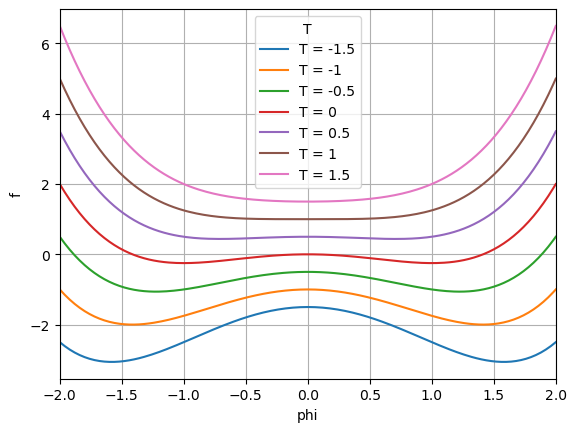

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Tc = 1
a0 = 1
a2 = 1
a4 = 1

phi = np.linspace(-2,2,201)
T = np.linspace(-1.5,1.5,7)

for Tk in T:
    f = a0*Tk + a2*(Tk-Tc)/2*phi**2 + a4*Tc/4*phi**4
    plt.plot(phi, f, label=fr"T = {Tk:.3g}")   # format how you like: .2f, .3g, etc.

plt.grid(True)
plt.legend(title="T", loc="best")  # or loc="upper right", ncol=2, etc.
plt.xlabel("phi"); plt.ylabel("f")
plt.grid(True)
plt.xlim(-2,2)
plt.show()


---
1D simulation. We implement a 1D finite difference method simulation using Landau free energy. In the code below, we will use two types of computing: 1) looping over grid points and 2) vectorized computing. 

* Here, we will use periodic boundary conditions.
* We will use an initial condition that $\phi$ is randomly distributed between `-0.5` and `0.5`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# --- params ---
Nx = 128*2

dx = 1.0
dt = 0.05

W = 0.0625;
K = 0.32;
L = 1.0
Tk = -1.5

# --- arrays / ICs ---
mu  = np.zeros(Nx)
phi = np.random.rand(Nx)*1 -0.5   # in (-0.5, 0.5)
Lap = np.zeros(Nx)
tm  = 0.0


from IPython.display import display, clear_output
import time

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Nx)

# --- time evolution ---
for iter in range(1, 2002):

    # loop over every point
    for p in range(1,Nx-1):
        # Laplacian
        Lap[p] = (phi[p-1] - 2.0*phi[p] + phi[p+1])/dx**2
        # chemical potential
        fprime = a2*(Tk-Tc)*phi[p] + a4*Tc*phi[p]**3
        mu[p] = W*fprime - K*Lap[p]

    # time updating
    for p in range(1,Nx-1):
        phi[p] = phi[p] -dt*L*mu[p]

    # vectorized computing
    # Laplacian (1D, interior)
    # Lap[1:-1] = (phi[:-2] - 2.0*phi[1:-1] + phi[2:]) / (dx*dx)

    # # chemical potential (interior)
    # fprime = a2*(Tk-Tc) * phi[1:-1] + a4*Tc*phi[1:-1]**3
    # mu[1:-1] = W * fprime - K * Lap[1:-1]

    # # explicit update
    # phi[1:-1] -= dt * L * mu[1:-1]

    # periodic ghost-cell style BCs
    phi[0]  = phi[-2]
    phi[-1] = phi[1]

    tm += dt

    # visualization
    if iter % 10 == 1:

        plt.plot(phi, '.-', markerfacecolor='none', label=f"t={tm:.0f}")
        plt.axis([0, Nx, -1.7, 1.7])
        plt.grid(True)
        plt.xlabel('x')
        plt.ylabel('phi')
   
        # Animaiton part (dosn't change)
        clear_output(wait=True) # Clear output for dynamic display
        display(fig)            # Reset display
        fig.clear()             # Prevent overlapping and layered plots
        time.sleep(0.02)         # Sleep for half a second to slow down the animation
        

---
In 2D 

$$\frac{\partial \phi}{\partial t} = -L \bigg[\frac{\partial f}{\partial \phi} -K \bigg(\frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2} \bigg) \bigg]$$

Finite difference stencil:

$$\frac{\phi_{i,j}^{(n+1)}-\phi_{i,j}^{(n)}}{\Delta t} = -L \bigg[\bigg(\frac{\partial f}{\partial \phi}\bigg)_{i,j}^{n} -K \bigg( \frac{\phi_{i,j-1}^{n} - 2\phi_{i,j}^{n} + \phi_{i,j+1}^{n}}{\Delta x^2} +  \frac{\phi_{i-1,j}^{n} - 2\phi_{i,j}^{n} + \phi_{i+1,j}^{n}}{\Delta y^2}\bigg) \bigg]$$

or 

$$\phi_{i,j}^{(n+1)} = \phi_{i,j}^{(n)} - \Delta t L \bigg[\bigg(\frac{\partial f}{\partial \phi}\bigg)_{i,j}^{n} -K \bigg( \frac{\phi_{i,j-1}^{n} - 2\phi_{i,j}^{n} + \phi_{i,j+1}^{n}}{\Delta x^2} +  \frac{\phi_{i-1,j}^{n} - 2\phi_{i,j}^{n} + \phi_{i+1,j}^{n}}{\Delta y^2}\bigg) \bigg]$$

We can try different temperatures, e.g., $T = -1.5$ or $T= 1$.

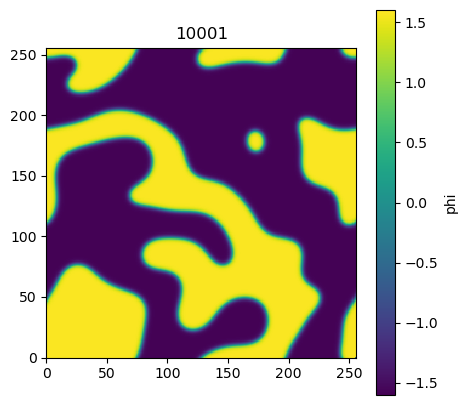

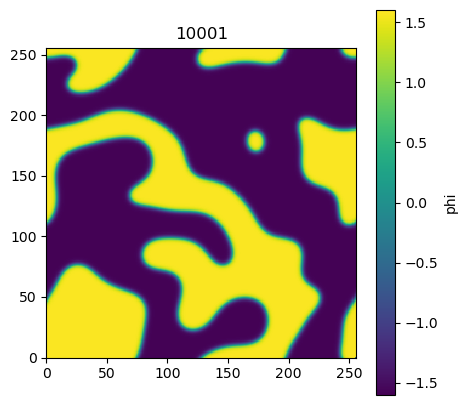

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# --- params ---
Nx = 128*2
Ny = Nx

dx = 1.0
dt = 0.05

W = 0.0625;
K = 0.32;
L = 1.0
Tk = -1.5
# Tk = 1

# --- arrays / ICs ---
mu  = np.zeros((Nx,Ny))
phi = np.random.rand(Nx,Ny)*1 - 0.5   # in (-0.5, 0.5)
Lap = np.zeros((Nx,Ny))
tm  = 0.0


from IPython.display import display, clear_output
import time

vmin, vmax = -1.6, 1.6   # set to what you want

fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(phi, origin='upper', interpolation='nearest',
               vmin=vmin, vmax=vmax, cmap='viridis')   # <- caxis via vmin/vmax
cbar = fig.colorbar(im, ax=ax, label='phi')            # <- colorbar once
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Nx)
ax.set_ylim(0, Ny)


# --- time evolution ---
for iter in range(1, 10002):


    # loop over every point
    # for p in range(1,Nx-1):
    #     for q in range(1,Ny-1):
    #         # Laplacian
    #         Lap[p,q] = (phi[p-1,q] - 2.0*phi[p,q] + phi[p+1,q])/dx**2 + \
    #                    (phi[p,q-1] - 2.0*phi[p,q] + phi[p,q+1])/dx**2
    #         # chemical potential
    #         fprime = a2*(Tk-Tc)*phi[p,q] + a4*Tc*phi[p,q]**3
    #         mu[p,q] = W*fprime - K*Lap[p,q]

    # # time updating
    # for p in range(1,Nx-1):
    #     for q in range(1,Ny-1):        
    #         phi[p,q] = phi[p,q] -dt*L*mu[p,q]

            
    # vectorized computing
    # Laplace
    Lap[1:-1,1:-1] = (phi[:-2,1:-1] - 2.0*phi[1:-1,1:-1] + phi[2:,1:-1]) / (dx*dx) + \
                     (phi[1:-1,:-2] - 2.0*phi[1:-1,1:-1] + phi[1:-1,2:]) / (dx*dx) 

    # chemical potential (interior)
    fprime = a2*(Tk-Tc) * phi[1:-1,1:-1] + a4*Tc*phi[1:-1,1:-1]**3
    mu[1:-1,1:-1] = W * fprime - K * Lap[1:-1,1:-1]

    # explicit update
    phi[1:-1,1:-1] -= dt * L * mu[1:-1,1:-1]
    

    # periodic ghost-cell style BCs
    phi[0,1:-1]  = phi[-2,1:-1]
    phi[-1,1:-1] = phi[1,1:-1]
    phi[1:-1,0]  = phi[1:-1,-2]
    phi[1:-1,-1] = phi[1:-1,1]
    

    tm += dt

    # visualization
    if iter % 20 == 1:
        im.set_data(phi)                 # update image only
        ax.set_title(f"{iter}")
        
        # Animaiton part (dosn't change)
        clear_output(wait=True) # Clear output for dynamic display
        display(fig)            # Reset display
        # fig.clear()             # Prevent overlapping and layered plots
        time.sleep(0.0002)         # Sleep for half a second to slow down the animation  

**The simulation results shall resemble the Ising model** as Landau model is the continuum version of Ising model of magnetization.  